# Projet ML - Prix de l'immobilier a Paris (jusqu'a l'EDA)

Ce notebook couvre les sections **1. Probleme**, **2. Donnees** et **3. EDA** du projet.

Le jeu de donnees est telecharge directement depuis les fichiers DVF (Data.gouv).

## 1. Probleme

### Contexte
Le marche immobilier parisien est heterogene selon les arrondissements, la surface et la date de transaction.

### Objectif metier
Construire une base analytique fiable pour predire et expliquer le **prix au m2** des appartements a Paris.

Cette etape (jusqu'a l'EDA) permet de:
- qualifier la qualite des donnees,
- identifier les facteurs principaux de variation,
- preparer le pipeline de modelisation (regression + comparaison de modeles) pour la suite.

## 2. Donnees

### Source
- Donnees DVF geolocalisees: https://files.data.gouv.fr/geo-dvf/latest/csv/
- Fichiers departementaux (Paris = departement 75), compression gzip.

### Description rapide
Colonnes clefs utilisees:
- `date_mutation`, `nature_mutation`, `valeur_fonciere`
- `type_local`, `surface_reelle_bati`, `nombre_pieces_principales`
- `code_postal`, `nom_commune`, `longitude`, `latitude`

### Limitations
- Presences de valeurs manquantes et outliers.
- Variabilite temporelle (inflation, cycle de marche).
- Variables explicatives partielles (etat du bien, etage, vue, etc. absents).

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Telechargement direct de DVF Paris (fallback 2021 si 2022 indisponible)
DATA_DIR = Path('data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

url_candidates = [
    'https://files.data.gouv.fr/geo-dvf/latest/csv/2022/departements/75.csv.gz',
    'https://files.data.gouv.fr/geo-dvf/latest/csv/2021/departements/75.csv.gz'
]

df_raw = None
used_url = None

for url in url_candidates:
    try:
        tmp = pd.read_csv(url, compression='gzip', low_memory=False)
        if len(tmp) > 0:
            df_raw = tmp
            used_url = url
            break
    except Exception as e:
        print(f'URL indisponible: {url} | {e}')

if df_raw is None:
    raise RuntimeError('Impossible de charger les donnees DVF Paris depuis les URLs candidates.')

print('Source utilisee:', used_url)
print('Dimensions initiales:', df_raw.shape)
df_raw.head(3)

Source utilisee: https://files.data.gouv.fr/geo-dvf/latest/csv/2022/departements/75.csv.gz
Dimensions initiales: (98308, 40)


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2022-1641189,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,75018.0,...,Appartement,25.0,2.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.88449
1,2022-1641189,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,75018.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.88449
2,2022-1641189,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,75018.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.88449


In [3]:
# Apercu structure
display(df_raw.info())
display(df_raw.describe(include='all').T.head(15))

<class 'pandas.DataFrame'>
RangeIndex: 98308 entries, 0 to 98307
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_mutation                   98308 non-null  str    
 1   date_mutation                 98308 non-null  str    
 2   numero_disposition            98308 non-null  int64  
 3   nature_mutation               98308 non-null  str    
 4   valeur_fonciere               96160 non-null  float64
 5   adresse_numero                97860 non-null  float64
 6   adresse_suffixe               4152 non-null   str    
 7   adresse_nom_voie              97877 non-null  str    
 8   adresse_code_voie             97877 non-null  str    
 9   code_postal                   97877 non-null  float64
 10  code_commune                  98308 non-null  int64  
 11  nom_commune                   98308 non-null  str    
 12  code_departement              98308 non-null  int64  
 13  ancien_code_

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_mutation,98308,47240,2022-1671153,988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_mutation,98308,302,2022-04-19,2359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numero_disposition,98308.0,NaN,NaN,NaN,1.008545,0.101402,1.0,1.0,1.0,1.0,6.0
nature_mutation,98308,5,Vente,96421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valeur_fonciere,96160.0,NaN,NaN,NaN,3437951.33807,24016908.844788,0.15,290000.0,531375.0,1100000.0,1003401470.0
adresse_numero,97860.0,NaN,NaN,NaN,51.84765,152.822455,1.0,11.0,28.0,66.0,9999.0
adresse_suffixe,4152,11,B,3237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adresse_nom_voie,97877,3442,RUE DE VAUGIRARD,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adresse_code_voie,97877,3431,9624,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_postal,97877.0,NaN,NaN,NaN,75013.278074,4.79248,75001.0,75010.0,75015.0,75017.0,75020.0


In [4]:
# Nettoyage minimal pour l'EDA (pas de fuite de donnees: simple preparation descriptive)
df = df_raw.copy()

# Typage
df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce')

# Variables numeriques utiles
for col in ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Filtrage business: ventes d'appartements a Paris
if 'nature_mutation' in df.columns:
    df = df[df['nature_mutation'].str.lower().eq('vente')]
if 'type_local' in df.columns:
    df = df[df['type_local'].str.lower().eq('appartement')]
if 'nom_commune' in df.columns:
    # nom_commune = 'Paris Xe Arrondissement', donc on filtre par startswith
    df = df[df['nom_commune'].str.upper().str.startswith('PARIS')]

# Variables derivees
df = df[df['surface_reelle_bati'] > 0]
df = df[df['valeur_fonciere'] > 0]
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

if 'code_postal' in df.columns:
    df['code_postal'] = pd.to_numeric(df['code_postal'], errors='coerce')
    df['arrondissement'] = (df['code_postal'] - 75000).astype('Int64')

# Suppression des outliers tres extremes (1%-99%) uniquement pour visualisation robuste
if len(df) > 0 and df['prix_m2'].notna().sum() > 0:
    q_low, q_high = df['prix_m2'].quantile([0.01, 0.99])
    df = df[(df['prix_m2'] >= q_low) & (df['prix_m2'] <= q_high)]

print('Dimensions apres filtrage:', df.shape)
df[['date_mutation', 'valeur_fonciere', 'surface_reelle_bati', 'prix_m2']].head()

Dimensions apres filtrage: (41624, 42)


,date_mutation,valeur_fonciere,surface_reelle_bati,prix_m2
0,2022-01-04,580000.0,25.0,23200.000000
3,2022-01-04,580000.0,20.0,29000.000000
5,2022-01-06,605000.0,42.0,14404.761905
9,2022-01-05,716250.0,69.0,10380.434783
13,2022-01-05,320000.0,33.0,9696.969697


## 3. Analyse exploratoire des donnees (EDA)

In [5]:
# Valeurs manquantes (top)
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing = missing[missing > 0]
missing.head(15).to_frame('pct_missing')

,pct_missing
ancien_nom_commune,100.00
nature_culture_speciale,100.00
numero_volume,100.00
ancien_id_parcelle,100.00
ancien_code_commune,100.00
code_nature_culture_speciale,100.00
lot5_surface_carrez,99.91
lot4_surface_carrez,99.63
lot5_numero,98.98
lot3_surface_carrez,98.63


count    4.162400e+04
mean     3.024802e+04
std      8.835179e+04
min      5.769231e+01
10%      7.674065e+03
25%      9.423077e+03
50%      1.116279e+04
75%      1.390356e+04
90%      2.926869e+04
max      1.045761e+06
Name: prix_m2, dtype: float64

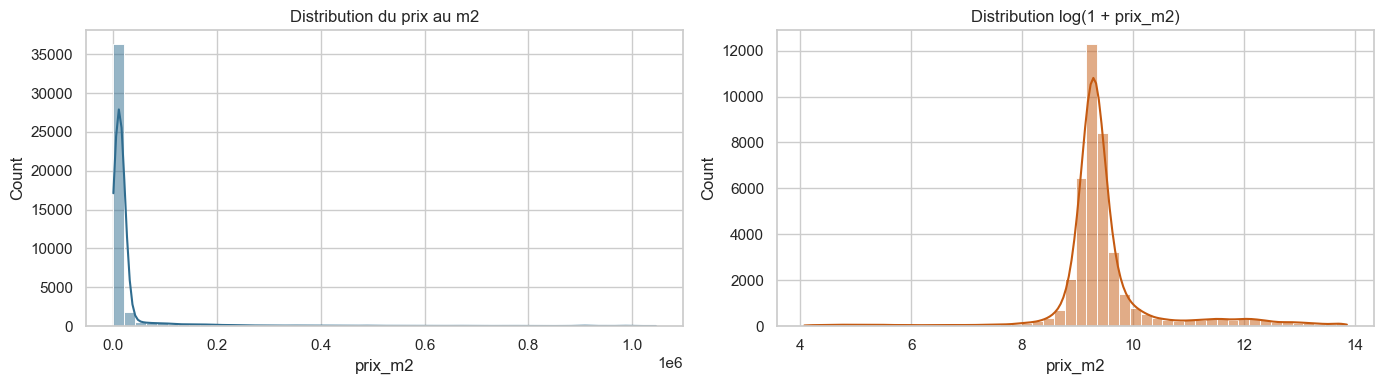

In [6]:
# Statistiques descriptives sur la cible analytique
display(df['prix_m2'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['prix_m2'], bins=50, kde=True, ax=axes[0], color='#2f6c8f')
axes[0].set_title('Distribution du prix au m2')

sns.histplot(np.log1p(df['prix_m2']), bins=50, kde=True, ax=axes[1], color='#c55a11')
axes[1].set_title('Distribution log(1 + prix_m2)')
plt.tight_layout()
plt.show()

,count,median,mean
arrondissement,,,
1,496,14166.091954,47089.606487
2,599,12223.517241,40180.812689
3,962,12943.238587,37042.787261
4,690,13716.517857,32975.756007
5,1166,13125.000000,20990.710466
6,1162,16058.015873,41586.814346
7,1290,15525.470457,32108.375109
8,978,13652.660075,57312.446373
9,1656,12000.000000,27438.763590


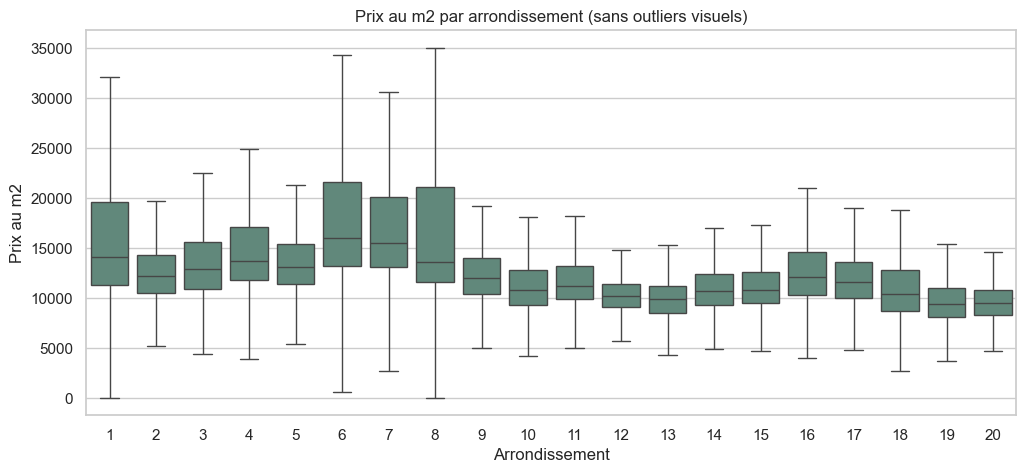

In [7]:
# Prix au m2 par arrondissement (si disponible)
if 'arrondissement' in df.columns:
    arr_stats = (
        df.dropna(subset=['arrondissement'])
          .groupby('arrondissement')['prix_m2']
          .agg(['count', 'median', 'mean'])
          .sort_index()
    )
    display(arr_stats)

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df[df['arrondissement'].between(1, 20, inclusive='both')],
                x='arrondissement', y='prix_m2',
                color='#5b8e7d', showfliers=False)
    plt.title('Prix au m2 par arrondissement (sans outliers visuels)')
    plt.xlabel('Arrondissement')
    plt.ylabel('Prix au m2')
    plt.show()

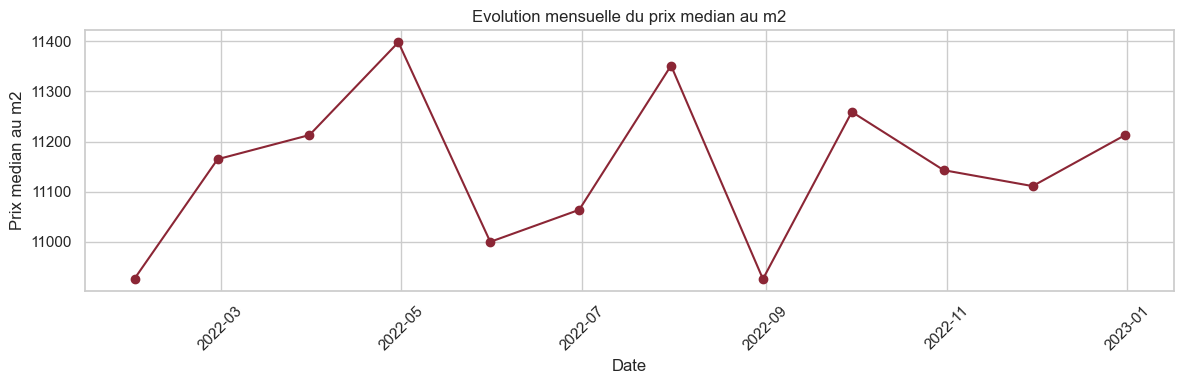

In [8]:
# Evolution mensuelle du prix median
monthly = (
    df.dropna(subset=['date_mutation'])
      .set_index('date_mutation')
      .resample('ME')['prix_m2']
      .median()
      .dropna()
)

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, marker='o', color='#8b2635')
plt.title('Evolution mensuelle du prix median au m2')
plt.xlabel('Date')
plt.ylabel('Prix median au m2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

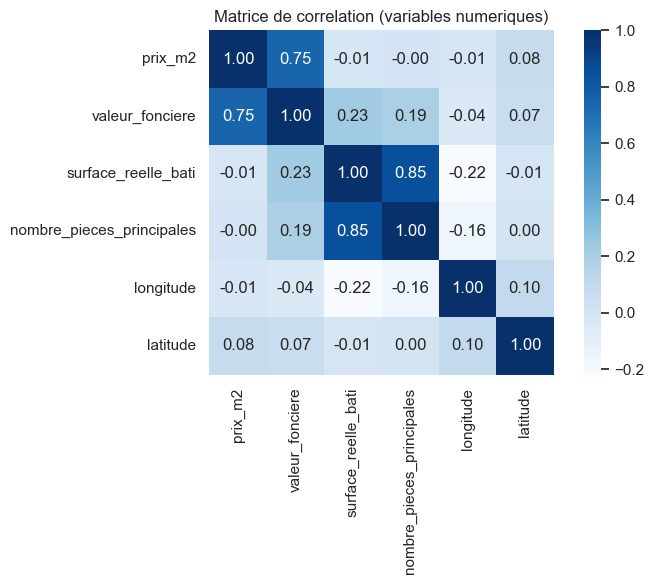

In [9]:
# Correlations numeriques
num_cols = [c for c in ['prix_m2', 'valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude'] if c in df.columns]
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Matrice de correlation (variables numeriques)')
plt.tight_layout()
plt.show()

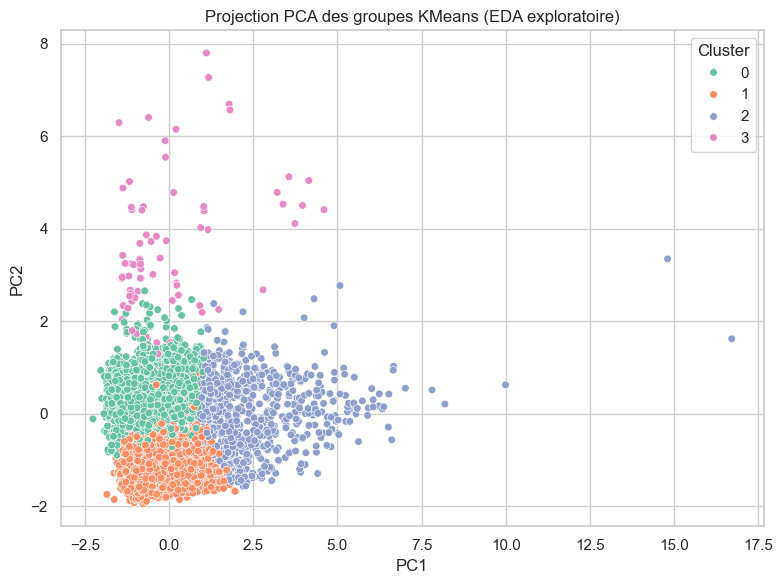

In [10]:
# Apercu non supervise (exploratoire): clustering KMeans sur features normalisees
cluster_cols = [c for c in ['surface_reelle_bati', 'nombre_pieces_principales', 'prix_m2', 'longitude', 'latitude'] if c in df.columns]
tmp = df[cluster_cols].dropna().copy()

if len(tmp) > 500:
    tmp = tmp.sample(5000, random_state=42) if len(tmp) > 5000 else tmp

if len(tmp) >= 100 and len(cluster_cols) >= 3:
    X = StandardScaler().fit_transform(tmp)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
    clusters = kmeans.fit_predict(X)

    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)

    eda_unsup = pd.DataFrame({'PC1': Z[:, 0], 'PC2': Z[:, 1], 'cluster': clusters})

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=eda_unsup, x='PC1', y='PC2', hue='cluster', palette='Set2', s=30)
    plt.title('Projection PCA des groupes KMeans (EDA exploratoire)')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()
else:
    print('Donnees insuffisantes pour la visualisation non supervisee.')